In [9]:
import os, numpy as np, agama, scipy.special, scipy.integrate, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import Latex

agama.setUnits(length=1, velocity=1, mass=1)
#working in kiloparsec, km/s and M_sun



In [17]:
pot_sun_ideal = agama.Potential(dict(type='Plummer', mass =1, scaleRadius=2.2*1e-11))
pot_sun=agama.Potential(potential=pot_sun_ideal,center=[0,0,0])

In [18]:
pot_sun.potential([0,0,1]),agama.G

(-4.300917270677361e-06, 4.30091727067736e-06)

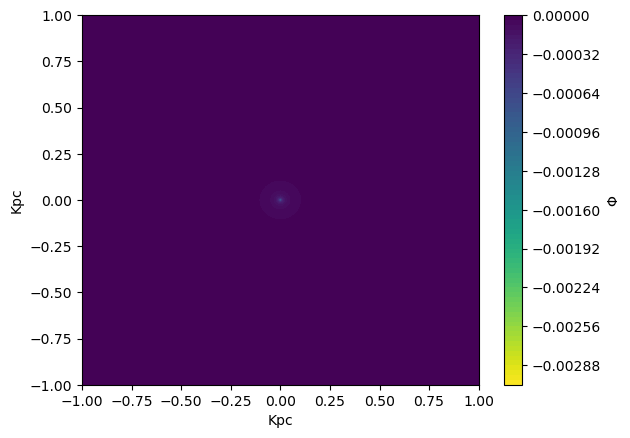

In [38]:
limit=1
x = np.linspace(-1*limit, limit, 1000)
y = np.linspace(-1*limit, limit, 1000)
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = pot_sun.potential(points).reshape(X.shape)

plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.xlabel('Kpc')
plt.ylabel('Kpc')
plt.colorbar(label='Φ')
#plt.scatter(0.000025,0.000025,c='k')

In [41]:
mc_mass0=1e-6
mc_rvir=1e-3
mc_rs=1e-4
Nbody=1000

pot_mc_nfw  = agama.Potential(type='spheroid', gamma=1, beta=3, scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)
df_mc = agama.DistributionFunction(type='quasispherical', potential=pot_mc_nfw)
mc_mass0 = pot_mc_nfw.totalMass()
print('Minicluster mass in M_sun',mc_mass0)

mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc_nfw, df_mc).sample(Nbody)

mcp_pot0=agama.Potential(type='multipole', particles=(mcp_xv[:,0:3] , mcp_mass), symmetry='n', lmax=50)


Minicluster mass in M_sun 9.999999999999997e-07


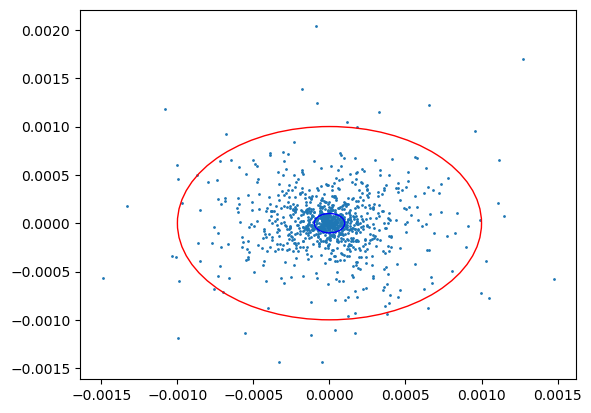

In [43]:
plt.scatter(mcp_xv[:,0],mcp_xv[:,1],s=1)

circle_rvir = plt.Circle((0, 0), mc_rvir, color='r', fill=False, label=f'r_vir={mc_rvir}')
circle_rs = plt.Circle((0, 0), mc_rs, color='b', fill=False, label=f'r_s={mc_rs}')
plt.gca().add_patch(circle_rvir)
plt.gca().add_patch(circle_rs)


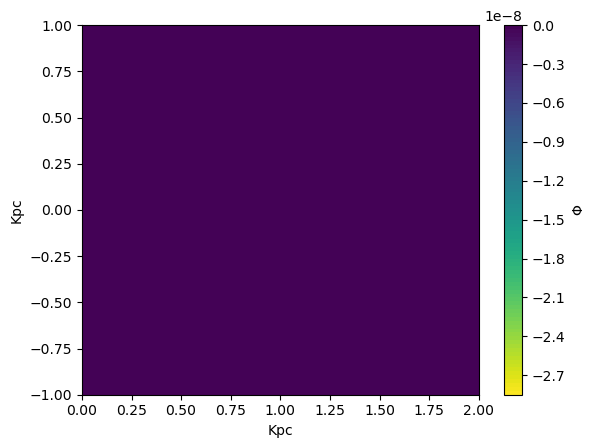

In [44]:
mcp_pot=agama.Potential(potential=mcp_pot0,center=[1e-5,1e-3,0])
x = np.linspace(0, 2, 1000)
y = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = mcp_pot.potential(points).reshape(X.shape)

plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.xlabel('Kpc')
plt.ylabel('Kpc')
plt.colorbar(label='Φ')
KE = 0.5 * np.sum(mcp_xv[:, 3:]**2, axis=1)

#plt.scatter(mcp_xv[:, 0], mcp_xv[:, 1], c=KE, s=2, cmap='viridis')

#plt.scatter(mcp_xv[:,0],mcp_xv[:,1],s=0.2,color='k')

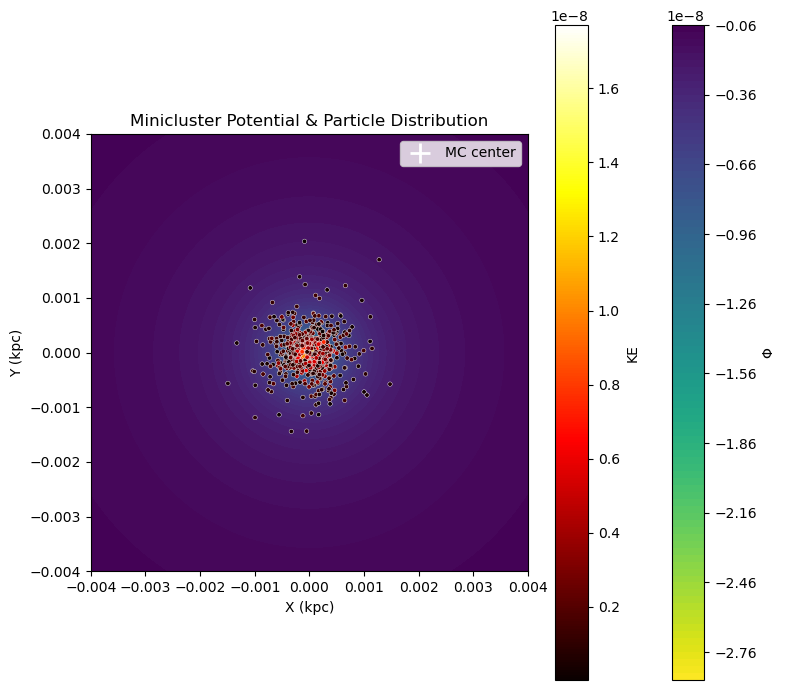

In [51]:
# --- Offset minicluster potential ---
mc_center = [0, 0, 0]
mcp_pot = agama.Potential(potential=mcp_pot0, center=mc_center)

# --- Create 2D evaluation grid in the X-Y plane ---
ngrid = 500
x = np.linspace(-0.004, 0.004, ngrid)
y = np.linspace(-0.004, 0.004, ngrid)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])

# --- Evaluate gravitational potential on the grid ---
Phi = mcp_pot.potential(points).reshape(X.shape)

# --- Particle kinetic energy ---
KE = 0.5 * np.sum(mcp_xv[:, 3:]**2, axis=1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))

# Potential contour map
cf = ax.contourf(X, Y, Phi, levels=100, cmap='viridis_r')
fig.colorbar(cf, ax=ax, label=r'$\Phi$')

# Overlay particles colored by kinetic energy
sc = ax.scatter(mcp_xv[:, 0] + mc_center[0],mcp_xv[:, 1] + mc_center[1],c=KE, s=10, cmap='hot', edgecolors='white', linewidths=0.3,zorder=5)
fig.colorbar(sc, ax=ax, label=r'KE')

# Mark the center
ax.plot(*mc_center[:2], 'w+', ms=15, mew=2, label='MC center')

ax.set_xlabel('X (kpc)')
ax.set_ylabel('Y (kpc)')
ax.set_title('Minicluster Potential & Particle Distribution')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [52]:
pot_total=agama.Potential(pot_sun, mcp_pot)

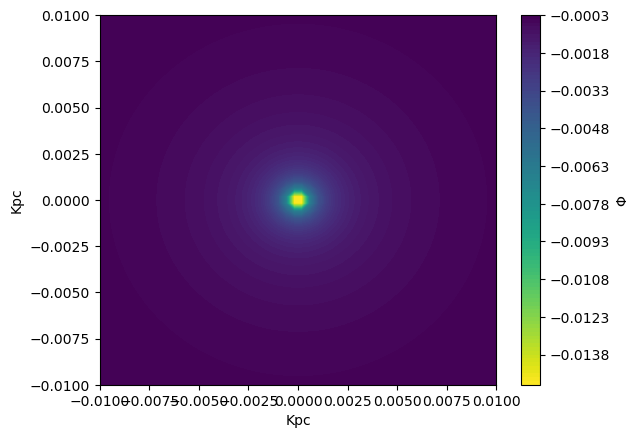

In [53]:
limit=0.01
x = np.linspace(-1*limit, limit, 50)
y = np.linspace(-1*limit, limit , 50)
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = pot_total.potential(points).reshape(X.shape)

plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.xlabel('Kpc')
plt.ylabel('Kpc')
plt.colorbar(label='Φ')
#KE = 0.5 * np.sum(mcp_xv[:, 3:]**2, axis=1)so

#plt.scatter(mcp_xv[:, 0], mcp_xv[:, 1], c=KE, s=2, cmap='viridis')

#plt.scatter(mcp_xv[:,0],mcp_xv[:,1],s=0.2,color='k')